In [1]:
import pandas as pd
import numpy as np
import glob
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from decimal import Decimal, getcontext

Dzielenie cięciw ze względu na metodę.

Accuracy: 0.5316


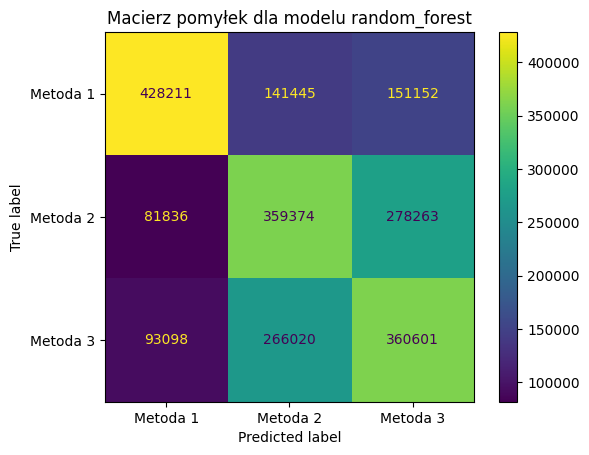

x1: 0.121
y1: 0.128
x2: 0.123
y2: 0.127
length: 0.121
center_x: 0.129
center_y: 0.128
distance_from_center: 0.123


['model_random_forest.pkl']

In [2]:
from pandas.core.series import Series


from typing import Any


from pandas.core.frame import DataFrame


method_1_files=glob.glob("../dane/metoda_1_*.csv")
method_2_files=glob.glob("../dane/metoda_2_*.csv")
method_3_files=glob.glob("../dane/metoda_3_*.csv")

def load_and_process(filepaths,method_label):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['method']=method_label
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

df1=load_and_process(method_1_files,method_label=1)
df2=load_and_process(method_2_files,method_label=2)
df3=load_and_process(method_3_files,method_label=3)
data=pd.concat([df1,df2,df3],ignore_index=True)

features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
X=data[features]
y: Series | Any | DataFrame=data['method']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(f'Accuracy: {acc:.4f}')

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Metoda 1','Metoda 2','Metoda 3'])
disp.plot()
plt.title('Macierz pomyłek dla modelu random_forest')
plt.savefig('macierz_pomyłek_dla_random_forest.png',dpi=300,bbox_inches='tight')
plt.show()

importance_of_features=model.feature_importances_
for f, imp in zip(features, importance_of_features):
    print(f'{f}: {imp:.3f}')
joblib.dump(model,'model_random_forest.pkl')

Dzielenie cięciw ze względu na metodę i długość.

In [2]:
method_1_files=glob.glob("../dane/metoda_1_*.csv")
method_2_files=glob.glob("../dane/metoda_2_*.csv")
method_3_files=glob.glob("../dane/metoda_3_*.csv")

def load_and_process(filepaths,method_label):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['method']=method_label
        df['class']=(method_label-1)*2+df['is_longer']+1
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

df1=load_and_process(method_1_files,method_label=1)
df2=load_and_process(method_2_files,method_label=2)
df3=load_and_process(method_3_files,method_label=3)
data=pd.concat([df1,df2,df3],ignore_index=True)

features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
X=data[features]
y=data['class']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(f'Accuracy: {acc:.4f}')

labels=[1,2,3,4,5,6]
label_names=['Metoda 1-krótka','Metoda 1-długa','Metoda 2-krótka','Metoda 2-długa','Metoda 3-krótka','Metoda 3-długa']

cm=confusion_matrix(y_test,y_pred,labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
disp.plot()
plt.title('Macierz pomyłek dla modelu random_forest, metoda i długość cięciwy')
plt.tight_layout()
plt.savefig('macierz_pomyłek_dla_random_forest_metoda_i_długość_cięciwy.png',dpi=300)
plt.show()

importance_of_features=model.feature_importances_
for f, imp in zip(features, importance_of_features):
    print(f'{f}: {imp:.3f}')
joblib.dump(model,'model_random_forest_metoda_i_długość_cięciwy.pkl')

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

Dzielenie cięciw ze względu na metodę i długość, z wykorzystaiem neiwidocznych końcówek

In [ ]:
method_1_files=glob.glob("../dane/metoda_1_*.csv")
method_2_files=glob.glob("../dane/metoda_2_*.csv")
method_3_files=glob.glob("../dane/metoda_3_*.csv")

def load_and_process(filepaths,method_label,has_center=False):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path,dtype=str)
        
        numeric_cols=['x1','y1','x2','y2','center_x','center_y','length']
        df=split_float64_and_tail(df,numeric_cols)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['is_longer']=df['is_longer'].astype(int)
        df['method']=method_label
        df['class']=(method_label-1)*2+df['is_longer']+1
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

def split_float64_and_tail(df,columns):
    for col in columns:
        floats=[]
        tails=[]
        for v in df[col]:
            dec=Decimal(v)
            f64=Decimal(str(np.float64(v)))
            tail=dec-f64
            floats.append(float(f64))
            tails.append(float(tail))
        
        df[col]=floats
        df[f'{col}_koncowka']=tails
    return df

getcontext().prec=50

df1=load_and_process(method_1_files,method_label=1,has_center=False)
df2=load_and_process(method_2_files,method_label=2,has_center=True)
df3=load_and_process(method_3_files,method_label=3,has_center=True)
data=pd.concat([df1,df2,df3],ignore_index=True)

base_features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
tail_features=[f'{f}_koncowka' for f in ['x1','y1','x2','y2','length','center_x','center_y']]
features=base_features+tail_features
X=data[features].astype(float)
y=data['class']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model: RandomForestClassifier=RandomForestClassifier(n_estimators=50,random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(f'Accuracy: {acc:.4f}')

labels=[1,2,3,4,5,6]
label_names=['Metoda 1-krótka','Metoda 1-długa','Metoda 2-krótka','Metoda 2-długa','Metoda 3-krótka','Metoda 3-długa']

cm=confusion_matrix(y_test,y_pred,labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
disp.plot()
plt.title('Macierz pomyłek dla modelu random_forest, metoda i długość cięciwy z użyciem końcówek')
plt.tight_layout()
plt.savefig('macierz_pomyłek_dla_random_forest_metoda_i_długość_cięciwy_z_użyciem_końcówek.png',dpi=300)
plt.show()

importance_of_features=model.feature_importances_
for f, imp in zip(features, importance_of_features):
    print(f'{f}: {imp:.3f}')
joblib.dump(model,'model_random_forest_metoda_i_długość_cięciwy_z_użyciem_końcówek.pkl')